# Finite-section ISTM reconstruction for KdV

This notebook is a self-contained working notebook for the Section 9 numerical realization in `152.pdf`.
The paper's KdV convention is

$$
u_t - 6u u_x + u_{xxx}=0.$$

The workflow is:

1. compute scattering data $J^\pm$ from an initial potential,
2. evolve the scattering data by the ISTM laws,
3. solve the finite-section systems (9.2) and (9.3),
4. recover $u(x,t)$ from $a_0$ or $b_0$ using (2.19) and (2.20).

No RK/ETDRK time stepping is used for the KdV evolution in this notebook.

In [84]:
using Pkg

function find_repo_root(start=pwd())
    dir = abspath(start)
    while true
        if isfile(joinpath(dir, "152.pdf")) && isdir(joinpath(dir, "NumISTNext"))
            return dir
        end
        parent = dirname(dir)
        parent == dir && error("Could not find repository root from $start")
        dir = parent
    end
end

repo_root = find_repo_root()
Pkg.activate(joinpath(repo_root, "NumISTNext", "scripts"))
Pkg.instantiate()

using LinearAlgebra
using Statistics
using Printf
using Dierckx
using Plots

# Numeric aliases used throughout the notebook. Keeping them explicit makes it
# easier to switch precision later without hunting through the formulas.
const RealT = Float64
const ComplexT = ComplexF64

# The paper maps the real spectral variable rho to the unit-circle variable
# z=(1/2+i*rho)/(1/2-i*rho), so 1/2 and 2 appear throughout Sections 5 and 9.
const HALF = RealT(1) / RealT(2)
const TWO = RealT(2)
const PI_T = RealT(π)
const TWO_PI = TWO * PI_T

gr()
default(framestyle=:box, linewidth=3, legend=:topright)

# Runtime knobs:
# - RUN_MODE controls the direct-scattering grid and truncation size.
# - DERIVATIVE_METHOD controls the final derivative in (2.19)/(2.20).
# - DIRECT_EXAMPLE_BRANCH chooses how direct-data examples are plotted.
RUN_MODE = :paper  # :smoke is for quick notebook work; switch to :paper only for final validation
DERIVATIVE_METHOD = :spline  # paper-style derivative; :finite_difference is useful for quick debugging
DIRECT_EXAMPLE_BRANCH = :left # :left avoids the current direct s+ stitching artifact; :paper_stitch keeps the Section 9 split
PLOT_EXACT_INITIAL = true  # t=0 panels show the known input q(x), not noisy inverse-reconstruction tails

struct RunSettings
    direct_L::RealT      # half-width [-L,L] for Appendix A direct scattering
    direct_nx::Int       # number of direct-scattering grid nodes; odd keeps x=0 on the grid
    direct_Ncoeff::Int   # Appendix A Laguerre-series truncation for a,b,c,d
    inverse_Ns::Int      # finite-section truncation: solve for coefficients 0:Ns in (9.2)/(9.3)
    inverse_Ni::Int      # unit-circle quadrature nodes for the reflection integral (9.4)
    plot_nx::Int         # plotting grid size for reconstructed q(x,t)
end

function run_settings(mode::Symbol)
    mode == :smoke && return RunSettings(RealT(12), 2001, 24, 8, 2560, 801)
    mode == :paper && return RunSettings(RealT(15), 8001, 40, 20, 2548, 5501)
    error("RUN_MODE must be :smoke or :paper")
end

settings = run_settings(RUN_MODE)
example93_Ncoeff = RUN_MODE == :paper ? max(settings.direct_Ncoeff, 80) : settings.direct_Ncoeff
example93_Ns = RUN_MODE == :paper ? max(settings.inverse_Ns, 11) : max(settings.inverse_Ns, 9)
repo_root, settings

  Activating project at `~/Desktop/ResearchProjects/NumIST/NumISTNext/scripts`


("/Users/fudong/Desktop/ResearchProjects/NumIST", RunSettings(15.0, 8001, 40, 20, 2548, 5501))

## Basic formulas and paper examples

The notebook uses small Julia functions for the Section 9.3 initial data and exact Example 9.2 soliton. The Bessel function in Example 9.3 is evaluated through the integral representation used in the earlier notes.

In [85]:
# Basic profiles used in Section 9.3 of 152.pdf.
sech(x) = inv(cosh(x))

"""
    besselj0_quad(x; ntheta=512)

Numerically evaluate J0(x) using the cosine integral representation. This is
used only for the right branch of Example 9.3 initial data.
"""
function besselj0_quad(x; ntheta::Int=512)
    h = PI_T / ntheta
    s = HALF * (cos(x * sin(zero(RealT))) + cos(x * sin(PI_T)))
    for j in 1:ntheta-1
        θ = RealT(j) * h
        s += cos(x * sin(θ))
    end
    return h * s / PI_T
end

# Example 9.1 initial data: q(x)=x*exp(-x^2).
paper_example91_initial(x) = x * exp(-x^2)

# Example 9.2 initial soliton. Its exact scattering data are known, so it is
# the cleanest validation of the finite-section inverse step.
function paper_example92_initial(x; c=PI_T)
    return -c / 2 * sech(sqrt(c) * x / 2)^2
end

function paper_example92_exact(x, t; c=PI_T)
    return -c / 2 * sech(sqrt(c) * (x - c*t) / 2)^2
end

# Example 9.3 initial data. The value is continuous at x=0, but the first
# derivative has a one-sided jump, so a corner at x=0 is expected at t=0.
function paper_example93_initial(x)
    x < 0 && return exp(x) * cos(4x)
    return exp(-x) * besselj0_quad(2x)
end

section93_times = (;
    example91=[0.0, 0.08, 0.16],
    example92=[0.0, 0.5, 1.0],
    example93=[0.0, 0.015, 0.03],
)

(example91 = [0.0, 0.08, 0.16], example92 = [0.0, 0.5, 1.0], example93 = [0.0, 0.015, 0.03])

## Scattering data and time evolution

For the KdV convention in the paper,

$$s^\pm(\rho,t)=s^\pm(\rho)e^{\pm 8i\rho^3t},\qquad
\alpha_k^\pm(t)=\alpha_k^\pm e^{\pm 8\tau_k^3t}.$$

In [86]:
"""
    ZeroReflection()

Callable reflection coefficient for reflectionless data: s+(rho)=s-(rho)=0.
Example 9.2 uses this, so the reflection-integral terms in (6.4)-(6.7) vanish.
"""
struct ZeroReflection end
(::ZeroReflection)(rho) = zero(ComplexT)
const zero_reflection = ZeroReflection()

"""
    SampledReflection(reflection, Ni)

Cache the Ni midpoint samples used by the unit-circle quadrature (9.4). This
avoids repeatedly evaluating the same direct-scattering reflection function.
"""
struct SampledReflection{F}
    base::F                 # original callable reflection coefficient
    Ni::Int                 # number of theta samples on (-pi,pi)
    dθ::RealT               # theta spacing, 2*pi/Ni
    z::Vector{ComplexT}     # unit-circle nodes z=exp(i*theta)
    rho::Vector{RealT}      # mapped real spectral nodes rho
    values::Vector{ComplexT} # cached reflection values at rho nodes
end

function SampledReflection(reflection, Ni::Int)
    dθ = TWO_PI / Ni
    z = ComplexT[cis(-PI_T + (RealT(j) + HALF) * dθ) for j in 0:Ni-1]
    rho = RealT[real(im * (one(ComplexT) - zj) / (TWO * (one(ComplexT) + zj))) for zj in z]
    values = ComplexT[convert(ComplexT, reflection(rj)) for rj in rho]
    return SampledReflection(reflection, Ni, dθ, z, rho, values)
end

(sampled::SampledReflection)(rho) = sampled.base(rho)

"""
    ScatteringData(side, tau, alpha, reflection)

Container for the KdV scattering data used in Sections 4 and 9.

- side=:right means J+ data: s+(rho), alpha+_k, and system (9.2).
- side=:left means J- data: s-(rho), alpha-_k, and system (9.3).
- tau[k]>0 corresponds to the discrete eigenvalue lambda_k=-tau[k]^2.
- alpha[k] is the norming constant attached to that side.
"""
struct ScatteringData{F}
    side::Symbol            # :right for J+, :left for J-
    tau::Vector{RealT}      # positive sqrt(-lambda_k)
    alpha::Vector{RealT}    # norming constants alpha+ or alpha-
    reflection::F           # callable s+(rho) or s-(rho)
end

function ScatteringData(side::Symbol, tau, alpha, reflection=zero_reflection)
    side in (:right, :left) || throw(ArgumentError("side must be :right or :left"))
    tauv = RealT.(collect(tau))
    alphav = RealT.(collect(alpha))
    length(tauv) == length(alphav) || throw(ArgumentError("tau and alpha must have the same length"))
    all(>(zero(RealT)), tauv) || throw(ArgumentError("all tau values must be positive"))
    return ScatteringData(side, tauv, alphav, reflection)
end

"""
    evolve_scattering(data, t)

Apply the Section 4 KdV time laws: s±(rho,t)=s±(rho)*exp(±8im*rho^3*t)
and alpha±_k(t)=alpha±_k*exp(±8*tau_k^3*t).
"""
function evolve_scattering(data::ScatteringData, t::Real)
    sgn = data.side == :right ? one(RealT) : -one(RealT)
    alpha_t = data.alpha .* exp.(sgn .* RealT(8) .* data.tau.^3 .* RealT(t))
    reflection_t = data.reflection isa ZeroReflection ? zero_reflection :
        (rho -> data.reflection(rho) * exp(sgn * RealT(8) * im * rho^3 * RealT(t)))
    return ScatteringData(data.side, data.tau, alpha_t, reflection_t)
end

"""
    example92_scattering_data(; c=pi)

Exact reflectionless scattering data for Example 9.2. The single eigenvalue is
lambda=-(sqrt(c)/2)^2 and both norming constants are sqrt(c).
"""
function example92_scattering_data(; c=PI_T)
    tau = [sqrt(c) / 2]
    alpha = [sqrt(c)]
    return (;
        right=ScatteringData(:right, tau, alpha, zero_reflection),
        left=ScatteringData(:left, tau, alpha, zero_reflection),
    )
end

example92_scattering_data

## Section 9.2: finite-section inverse scattering

For known scattering data, the inverse step follows (9.2)-(9.4). The reflection integral is computed with the unit-circle transform

$$z=e^{i\theta}=\frac{1/2+i\rho}{1/2-i\rho},\qquad \theta\in(-\pi,\pi).$$

The final differentiation of $a_0$ or $b_0$ is the numerically delicate part of (2.19) and (2.20). The notebook includes the cubic-spline option used in the paper and a fourth-order finite-difference stencil for debugging. The setup cell currently uses `DERIVATIVE_METHOD = :spline`; switch to `:finite_difference` when you want a quick smoke-test comparison.

In [87]:
# (-1)^k occurs repeatedly in the Laguerre-basis finite-section systems.
@inline signpow(k::Integer) = isodd(k) ? -one(RealT) : one(RealT)

"""
    reflection_integral(reflection, x, m, n; Ni=10_000)

Compute the reflection integral in (6.4)-(6.7) after the unit-circle change
of variables (9.4), z=exp(i*theta)=(1/2+i*rho)/(1/2-i*rho).
"""
function reflection_integral(reflection, x::Real, m::Int, n::Int; Ni::Int=10_000)
    n - m >= 1 || throw(ArgumentError("expected n - m >= 1"))
    reflection isa ZeroReflection && return zero(ComplexT)
    dθ = TWO_PI / Ni
    total = zero(ComplexT)
    for j in 0:Ni-1
        θ = -PI_T + (RealT(j) + HALF) * dθ
        z = cis(θ)
        ρ = real(im * (one(ComplexT) - z) / (TWO * (one(ComplexT) + z)))
        total += reflection(ρ) * exp((z - 1) / (z + 1) * x) * z^(m + 1) * (z + 1)^(n - m - 2)
    end
    return dθ * total
end

# Same integral as above, but using cached reflection samples.
function reflection_integral(reflection::SampledReflection, x::Real, m::Int, n::Int; Ni::Int=reflection.Ni)
    n - m >= 1 || throw(ArgumentError("expected n - m >= 1"))
    reflection.Ni == Ni || return reflection_integral(reflection.base, x, m, n; Ni=Ni)
    total = zero(ComplexT)
    for j in eachindex(reflection.z)
        z = reflection.z[j]
        total += reflection.values[j] * exp((z - 1) / (z + 1) * x) * z^(m + 1) * (z + 1)^(n - m - 2)
    end
    return reflection.dθ * total
end

# Wrap a direct-scattering reflection function in SampledReflection before the
# inverse solve so each rho node is evaluated once per time slice.
function sample_reflection_for_inverse(reflection, Ni::Int)
    reflection isa ZeroReflection && return reflection
    reflection isa SampledReflection && reflection.Ni == Ni && return reflection
    return SampledReflection(reflection, Ni)
end

"""
    discrete_sum(data, x, power, denom_shift)

Bound-state sum from (6.4)-(6.7). These terms carry tau_k and alpha_k and are
assembled into the right-hand side and matrix of (9.2)/(9.3).
"""
function discrete_sum(data::ScatteringData, x::Real, power::Int, denom_shift::Int)
    expo_sign = data.side == :right ? -one(RealT) : one(RealT)
    value = zero(ComplexT)
    for (τ, α) in zip(data.tau, data.alpha)
        value += α * exp(expo_sign * TWO * τ * x) * (HALF - τ)^power / (HALF + τ)^(power + denom_shift)
    end
    return value
end

function reflection_term(data::ScatteringData, x::Real, m::Int, n::Int; Ni::Int)
    # The left Jost system is written with the reflected coordinate, hence -x.
    xeff = data.side == :right ? x : -x
    return reflection_integral(data.reflection, xeff, m, n; Ni=Ni) / TWO_PI
end

"""
    finite_section_coefficients(data, x; Ns=5, Ni=10_000)

Solve the truncated finite-section linear system at one spatial point. For
side=:right this is (9.2) and returns a0,a1,...; for side=:left this is (9.3)
and returns b0,b1,....
"""
function finite_section_coefficients(data::ScatteringData, x::Real; Ns::Int=5, Ni::Int=10_000)
    dim = Ns + 1
    M = Matrix{ComplexT}(I, dim, dim)
    rhs = zeros(ComplexT, dim)
    refl_mat = [reflection_term(data, x, p, p + 2; Ni=Ni) for p in 0:2Ns]
    refl_rhs = [reflection_term(data, x, m, m + 1; Ni=Ni) for m in 0:Ns]

    for m in 0:Ns
        rhs[m + 1] = signpow(m + 1) * (discrete_sum(data, x, m, 1) + refl_rhs[m + 1])
        for n in 0:Ns
            p = m + n
            M[m + 1, n + 1] += signpow(p) * (discrete_sum(data, x, p, 2) + refl_mat[p + 1])
        end
    end
    return M \ rhs
end

"""
    spline_derivatives(x, y)

Differentiate a0 or b0 with cubic splines, matching the paper's numerical
description for the final q recovery in (2.19)/(2.20).
"""
function spline_derivatives(x, y)
    xr = Float64.(x)
    yr = Float64.(real.(y))
    yi = Float64.(imag.(y))
    sr = Spline1D(xr, yr; k=3, s=0.0)
    si = Spline1D(xr, yi; k=3, s=0.0)
    dy = ComplexT[derivative(sr, Float64(xi)) + im * derivative(si, Float64(xi)) for xi in x]
    d2y = ComplexT[derivative(sr, Float64(xi); nu=2) + im * derivative(si, Float64(xi); nu=2) for xi in x]
    return dy, d2y
end

function grid_spacing_tolerance(h)
    spacing_eps = h isa AbstractFloat ? RealT(eps(typeof(h))) : eps(RealT)
    return RealT(10_000) * spacing_eps * max(one(RealT), abs(RealT(h)))
end

function grid_spacing_deviation(x, h)
    return maximum(RealT.(abs.((x[2:end] .- x[1:end-1]) .- h)))
end

"""
    finite_difference_1_2(x, y)

Return first and second derivatives on a uniform grid. This is a useful
debugging alternative to spline differentiation for (2.19)/(2.20).
"""
function finite_difference_1_2(x::AbstractVector, y::AbstractVector)
    n = length(x)
    n == length(y) || throw(ArgumentError("x and y must have equal length"))
    n >= 5 || throw(ArgumentError("need at least five grid points"))
    h = x[2] - x[1]
    grid_spacing_deviation(x, h) <= grid_spacing_tolerance(h) ||
        throw(ArgumentError("x must be uniformly spaced"))

    dy = similar(ComplexT.(y))
    d2y = similar(ComplexT.(y))
    dy[1] = (-3y[1] + 4y[2] - y[3]) / (2h)
    dy[end] = (3y[end] - 4y[end-1] + y[end-2]) / (2h)
    d2y[1] = (2y[1] - 5y[2] + 4y[3] - y[4]) / h^2
    d2y[end] = (2y[end] - 5y[end-1] + 4y[end-2]) / h^2

    for i in 2:n-1
        dy[i] = (y[i + 1] - y[i - 1]) / (2h)
        d2y[i] = (y[i + 1] - 2y[i] + y[i - 1]) / h^2
    end

    for i in 3:n-2
        dy[i] = (-y[i + 2] + 8y[i + 1] - 8y[i - 1] + y[i - 2]) / (12h)
        d2y[i] = (-y[i + 2] + 16y[i + 1] - 30y[i] + 16y[i - 1] - y[i - 2]) / (12h^2)
    end

    return dy, d2y
end

# Select the derivative backend for the final a0/b0 differentiation.
function coefficient_derivatives(x, y; method::Symbol=DERIVATIVE_METHOD)
    method == :finite_difference && return finite_difference_1_2(x, y)
    method == :spline && return spline_derivatives(x, y)
    throw(ArgumentError("DERIVATIVE_METHOD must be :finite_difference or :spline"))
end

# Return the uniform grid spacing, or nothing if the grid is not uniform.
function uniform_grid_step(x)
    length(x) >= 2 || return nothing
    h = x[2] - x[1]
    grid_spacing_deviation(x, h) <= grid_spacing_tolerance(h) || return nothing
    return h
end

"""
    recover_one_side(data, xgrid; Ns=5, Ni=10_000, derivative_pad=12)

Compute a one-sided inverse reconstruction over the full xgrid. The returned
coefficient is a0 for J+ data or b0 for J- data. `derivative_pad` adds extra
points before differentiating so endpoints of the plotted grid are less noisy.
"""
function recover_one_side(data::ScatteringData, xgrid; Ns::Int=5, Ni::Int=10_000, derivative_pad::Int=12)
    reflection = sample_reflection_for_inverse(data.reflection, Ni)
    local_data = ScatteringData(data.side, data.tau, data.alpha, reflection)

    h = uniform_grid_step(xgrid)
    pad = h === nothing ? 0 : derivative_pad
    work_x = pad == 0 ? xgrid : collect(range(first(xgrid) - pad*h; step=h, length=length(xgrid) + 2pad))
    c0_work = [finite_section_coefficients(local_data, x; Ns=Ns, Ni=Ni)[1] for x in work_x]
    dc0, d2c0 = coefficient_derivatives(work_x, c0_work)
    # Equations (2.19) and (2.20): recover q from a0 for J+ or b0 for J-.
    q_work = data.side == :right ? (d2c0 .- dc0) ./ (1 .+ c0_work) : (d2c0 .+ dc0) ./ (1 .+ c0_work)

    keep = pad == 0 ? eachindex(xgrid) : (pad + 1):(pad + length(xgrid))
    return real.(q_work[keep]), c0_work[keep]
end

"""
    local_stitch_gap(qright, qleft, xgrid; switch=0, window=0.25)

Measure max |qright-qleft| near the switch. For exact compatible data this
should be tiny; a large value flags the nonphysical stitch artifact.
"""
function local_stitch_gap(qright, qleft, xgrid; switch=0.0, window=RealT(0.25))
    idx = findall(x -> abs(RealT(x) - RealT(switch)) <= RealT(window), xgrid)
    isempty(idx) && return zero(RealT)
    return maximum(RealT.(abs.(qright[idx] .- qleft[idx])))
end

"""
    recover_potential(right_data, left_data, xgrid; branch=:paper_stitch)

Combine the one-sided inverses. `branch=:paper_stitch` follows the Section 9.3
split: (9.2)/J+ for x<switch and (9.3)/J- for x>=switch. `branch=:left` or
`:right` uses one side on the whole grid, which is often cleaner for direct
scattering data. The stitched result includes `stitch_gap` for diagnostics.
"""
function recover_potential(right_data::ScatteringData, left_data::ScatteringData, xgrid; Ns::Int=5, Ni::Int=10_000, switch=0.0, branch::Symbol=:paper_stitch)
    branch in (:paper_stitch, :left, :right) ||
        throw(ArgumentError("branch must be :paper_stitch, :left, or :right"))
    if branch == :left
        qleft, b0 = recover_one_side(left_data, xgrid; Ns=Ns, Ni=Ni)
        return (; q=qleft, qright=nothing, qleft, a0=nothing, b0, stitch_gap=nothing)
    elseif branch == :right
        qright, a0 = recover_one_side(right_data, xgrid; Ns=Ns, Ni=Ni)
        return (; q=qright, qright, qleft=nothing, a0, b0=nothing, stitch_gap=nothing)
    end
    qright, a0 = recover_one_side(right_data, xgrid; Ns=Ns, Ni=Ni)
    qleft, b0 = recover_one_side(left_data, xgrid; Ns=Ns, Ni=Ni)
    q = similar(qright)
    for i in eachindex(xgrid)
        # Section 9.3 uses (9.2), the a_m/right-data system, for x < 0,
        # and (9.3), the b_m/left-data system, for x > 0.
        q[i] = xgrid[i] < switch ? qright[i] : qleft[i]
    end
    return (; q, qright, qleft, a0, b0, stitch_gap=local_stitch_gap(qright, qleft, xgrid; switch=switch))
end

"""
    kdv_ist_solution(right0, left0, xgrid, t; branch=:paper_stitch)

Evolve the initial scattering data by Section 4, then reconstruct q(x,t) by
the finite-section inverse systems from Section 9.
"""
function kdv_ist_solution(right0::ScatteringData, left0::ScatteringData, xgrid, t; Ns::Int=5, Ni::Int=10_000, switch=0.0, branch::Symbol=:paper_stitch)
    return recover_potential(evolve_scattering(right0, t), evolve_scattering(left0, t), xgrid; Ns=Ns, Ni=Ni, switch=switch, branch=branch)
end

# Plot helper: keep exact t=0 initial profiles visible while using IST for t>0.
function plotted_kdv_profile(qfun, right0::ScatteringData, left0::ScatteringData, xgrid, t; Ns::Int=5, Ni::Int=10_000, switch=0.0, branch::Symbol=:paper_stitch)
    PLOT_EXACT_INITIAL && iszero(t) && return qfun.(xgrid)
    return kdv_ist_solution(right0, left0, xgrid, t; Ns=Ns, Ni=Ni, switch=switch, branch=branch).q
end

plotted_kdv_profile (generic function with 1 method)

## Section 9.1: direct scattering by Appendix A recurrence

The direct step follows the paper's Section 9.1 outline. First solve the seed equation

$$
-y''+q(x)y+\frac14 y=0
$$

with Jost asymptotic data for $e(i/2,x)$ and $g(i/2,x)$. Then compute $\eta$ and $\xi$ from (A.1)-(A.2), build the coefficients $a_n,b_n,c_n,d_n$ using the Appendix A recurrence, and evaluate the Section 5 formulas for eigenvalues, norming constants, and reflection coefficients. The seed Cauchy problem below is solved by the SPPS method from `sppsmethod.pdf`; KdV time evolution is still done solely by the IST scattering-data laws.

For high-accuracy paper reproduction, set `RUN_MODE = :paper` in the setup cell.

In [88]:
"""
    spps_powers(x, odd_weight, even_weight, Nmax)

Build the recursive SPPS formal powers used to solve the local Cauchy problem
for -y''+q*y=lambda*y. The alternating weights are the standard SPPS pattern.
"""
function spps_powers(x, odd_weight, even_weight, Nmax::Int)
    powers = Vector{Vector{ComplexT}}(undef, Nmax + 1)
    powers[1] = ones(ComplexT, length(x))
    for n in 1:Nmax
        weight = isodd(n) ? odd_weight : even_weight
        powers[n + 1] = ComplexT.(prefix_nc6(x, powers[n] .* weight))
    end
    return powers
end

# Local nonvanishing solution of the lambda=0 auxiliary problem used as the
# SPPS base solution on a short segment.
function local_zero_solution_spps(qfun, x; N0::Int=16)
    qv = ComplexT.(qfun.(x))
    onev = ones(ComplexT, length(x))
    Xt = spps_powers(x, qv, onev, 2N0)
    u0 = zeros(ComplexT, length(x))
    u0p = zeros(ComplexT, length(x))
    for k in 0:N0
        u0 .+= Xt[2k + 1]
        k > 0 && (u0p .+= Xt[2k])
    end
    minimum(abs.(u0)) > 1e-10 || throw(ArgumentError("local SPPS base solution nearly vanishes; use shorter segments"))
    return (; u0, u0p)
end

# Solve one Cauchy segment by SPPS. y0 and yp0 are the incoming value and
# derivative at the left endpoint of the segment.
function spps_cauchy_segment(qfun, x, λ, y0, yp0; N0::Int=16, Nt::Int=24)
    base = local_zero_solution_spps(qfun, x; N0=N0)
    u0, u0p = base.u0, base.u0p
    u02 = u0 .^ 2
    invu02 = inv.(u02)
    Xt = spps_powers(x, u02, invu02, 2Nt)
    X = spps_powers(x, invu02, u02, 2Nt + 1)

    S1 = zeros(ComplexT, length(x)); S1d = zeros(ComplexT, length(x))
    S2 = zeros(ComplexT, length(x)); S2d = zeros(ComplexT, length(x))
    λc = ComplexT(λ)
    for k in 0:Nt
        λk = λc^k
        S1 .+= λk .* Xt[2k + 1]
        k > 0 && (S1d .+= λk .* Xt[2k] .* invu02)
        S2 .+= λk .* X[2k + 2]
        S2d .+= λk .* X[2k + 1] .* invu02
    end

    u1 = u0 .* S1
    u1p = u0p .* S1 .+ u0 .* S1d
    u2 = u0 .* S2
    u2p = u0p .* S2 .+ u0 .* S2d
    c1 = y0 / u0[1]
    c2 = u0[1] * (yp0 - c1 * u0p[1])
    return c1 .* u1 .+ c2 .* u2, c1 .* u1p .+ c2 .* u2p
end

# March the SPPS Cauchy solve across the whole grid by stitching short
# segments; this is more stable than one long SPPS expansion.
function spps_cauchy_grid(qfun, x, λ, y0, yp0; segment_points::Int=21, N0::Int=16, Nt::Int=24)
    y = Vector{ComplexT}(undef, length(x))
    yp = similar(y)
    y[1] = y0
    yp[1] = yp0
    i = 1
    while i < length(x)
        j = min(length(x), i + segment_points - 1)
        ys, yps = spps_cauchy_segment(qfun, x[i:j], λ, y[i], yp[i]; N0=N0, Nt=Nt)
        y[i:j] .= ComplexT.(real.(ys))
        yp[i:j] .= ComplexT.(real.(yps))
        i = j
    end
    return y, yp
end

# Closed Newton-Cotes weights for prefix integrals used throughout Appendix A.
const NC_WEIGHTS = Dict(
    1 => RealT[1//2, 1//2],
    2 => RealT[1//3, 4//3, 1//3],
    3 => RealT[3//8, 9//8, 9//8, 3//8],
    4 => RealT[14//45, 64//45, 24//45, 64//45, 14//45],
    5 => RealT[95//288, 375//288, 250//288, 250//288, 375//288, 95//288],
)

function nc_segment_integral(values, h)
    k = length(values) - 1
    1 <= k <= 5 || throw(ArgumentError("Newton-Cotes segment must have 1 to 5 intervals"))
    return h * sum(NC_WEIGHTS[k] .* collect(values))
end

"""
    prefix_nc6(x, values)

Cumulative Newton-Cotes integral on a uniform grid. `integral_left_nc6` gives
int_{-L}^x and `integral_right_nc6` gives int_x^L, matching Appendix A.
"""
function prefix_nc6(x::AbstractVector, values::AbstractVector)
    n = length(x)
    n == length(values) || throw(ArgumentError("x and values must have equal length"))
    n >= 2 || throw(ArgumentError("need at least two nodes"))
    h = x[2] - x[1]
    grid_spacing_deviation(x, h) <= grid_spacing_tolerance(h) ||
        throw(ArgumentError("x must be uniformly spaced"))

    prefix = zeros(promote_type(eltype(values), RealT), n)
    i = 1
    while i < n
        k = min(5, n - i)
        for r in 1:k
            prefix[i + r] = prefix[i] + nc_segment_integral(@view(values[i:i+r]), h)
        end
        i += k
    end
    return prefix
end

integral_left_nc6(x, values) = prefix_nc6(x, values)
function integral_right_nc6(x, values)
    p = prefix_nc6(x, values)
    return p[end] .- p
end

"""
    seed_solutions_i_half(qfun; L, nx)

Compute the Jost seed solutions e(i/2,x) and g(i/2,x) for Section 9.1. The
right Jost solution e is integrated from +L backward; g is integrated from -L
forward. `mid` is the index of x=0, where Section 5 quantities are evaluated.
"""
function seed_solutions_i_half(qfun; L::Real=settings.direct_L, nx::Int=settings.direct_nx)
    isodd(nx) || throw(ArgumentError("nx must be odd so x=0 is on the grid"))
    Lb = RealT(L)
    x = collect(range(-Lb, Lb; length=nx))
    mid = (nx + 1) ÷ 2
    abs(x[mid]) < RealT(100) * eps(RealT) * max(one(RealT), Lb) || throw(ArgumentError("grid must contain x=0"))

    xr = reverse(x)
    er, epr = spps_cauchy_grid(qfun, xr, HALF^2, exp(-Lb / TWO), -HALF * exp(-Lb / TWO))
    gl, gpl = spps_cauchy_grid(qfun, x, HALF^2, exp(-Lb / TWO), HALF * exp(-Lb / TWO))

    return (; x, mid, e=real.(reverse(er)), ep=real.(reverse(epr)), g=real.(gl), gp=real.(gpl))
end

"""
    appendixA_coefficients(qfun; L, nx, Ncoeff)

Build the Appendix A Laguerre coefficients a_n,b_n,c_n,d_n and their first
derivatives. These feed the Section 5 formulas for phi(z), eigenvalues,
norming constants, and reflection coefficients.
"""
function appendixA_coefficients(qfun; L::Real=settings.direct_L, nx::Int=settings.direct_nx, Ncoeff::Int=settings.direct_Ncoeff)
    seed = seed_solutions_i_half(qfun; L=L, nx=nx)
    x, mid = seed.x, seed.mid
    e, ep, g, gp = seed.e, seed.ep, seed.g, seed.gp
    qv = RealT.(qfun.(x))
    exph = exp.(x ./ 2)
    expmh = exp.(-x ./ 2)

    # Appendix A auxiliary functions eta and xi are built from integrals of
    # 1/e^2 and 1/g^2, normalized at x=0.
    eint = prefix_nc6(x, inv.(e .^ 2))
    gint = prefix_nc6(x, inv.(g .^ 2))
    int_eta = eint .- eint[mid]
    int_xi = gint[mid] .- gint
    eta = e .* int_eta
    xi = g .* int_xi
    etap = ep .* int_eta .+ inv.(e)
    xip = gp .* int_xi .- inv.(g)

    # qleft/qright are the left and right indefinite integrals of the potential
    # that enter the n=0 c_0 and d_0 coefficients in Appendix A.
    qleft = integral_left_nc6(x, qv)
    qright = integral_right_nc6(x, qv)

    # Coefficient arrays: row n+1 stores the nth coefficient over the x-grid.
    # a,b represent the Jost-function expansions; c,d represent derivative
    # combinations needed by Section 5.
    a = zeros(RealT, Ncoeff + 1, nx)
    ap = zeros(RealT, Ncoeff + 1, nx)
    b = zeros(RealT, Ncoeff + 1, nx)
    bp = zeros(RealT, Ncoeff + 1, nx)
    d = zeros(RealT, Ncoeff + 1, nx)
    c = zeros(RealT, Ncoeff + 1, nx)

    a0 = e .* exph .- 1
    ap0 = (ep .+ HALF .* e) .* exph
    b0 = g .* expmh .- 1
    bp0 = (gp .- HALF .* g) .* expmh
    a[1, :] .= a0
    ap[1, :] .= ap0
    b[1, :] .= b0
    bp[1, :] .= bp0
    d[1, :] .= ap0 .- HALF .* a0 .+ HALF .* qright
    c[1, :] .= bp0 .+ HALF .* b0 .- HALF .* qleft

    # Appendix A basis combinations used in the recurrence. The trailing `p`
    # suffix means derivative with respect to x.
    p1 = e .* expmh
    p1p = (ep .- HALF .* e) .* expmh
    p2 = eta .* expmh
    p2p = (etap .- HALF .* eta) .* expmh
    q1 = g .* exph
    q1p = (gp .+ HALF .* g) .* exph
    q2 = xi .* exph
    q2p = (xip .+ HALF .* xi) .* exph
    r1 = eta .* exph
    r1p = (etap .+ HALF .* eta) .* exph
    r2 = e .* exph
    r2p = (ep .+ HALF .* e) .* exph
    s1 = xi .* expmh
    s1p = (xip .- HALF .* xi) .* expmh
    s2 = g .* expmh
    s2p = (gp .- HALF .* g) .* expmh

    # Running integral accumulators for the Appendix A recurrence.
    J1 = zeros(RealT, nx); J2 = zeros(RealT, nx)
    I1 = zeros(RealT, nx); I2 = zeros(RealT, nx)
    J1p = zeros(RealT, nx); J2p = zeros(RealT, nx)
    I1p = zeros(RealT, nx); I2p = zeros(RealT, nx)

    for n in 1:Ncoeff
        aprevious = @view a[n, :]
        apprevious = @view ap[n, :]
        bprevious = @view b[n, :]
        bpprevious = @view bp[n, :]

        J1new = J1 .- p1 .* aprevious .- integral_right_nc6(x, p1p .* aprevious)
        J2new = J2 .- p2 .* aprevious .- integral_right_nc6(x, p2p .* aprevious)
        I1new = I1 .+ q1 .* bprevious .- integral_left_nc6(x, q1p .* bprevious)
        I2new = I2 .+ q2 .* bprevious .- integral_left_nc6(x, q2p .* bprevious)

        J1pnew = J1p .- p1 .* apprevious
        J2pnew = J2p .- p2 .* apprevious
        I1pnew = I1p .+ q1 .* bpprevious
        I2pnew = I2p .+ q2 .* bpprevious

        anew = a0 .- 2 .* (r1 .* J1new .- r2 .* J2new)
        apnew = ap0 .- 2 .* r1p .* J1new .- 2 .* r1 .* J1pnew .+ 2 .* r2p .* J2new .+ 2 .* r2 .* J2pnew
        bnew = b0 .+ 2 .* (s1 .* I1new .- s2 .* I2new)
        bpnew = bp0 .+ 2 .* s1p .* I1new .+ 2 .* s1 .* I1pnew .- 2 .* s2p .* I2new .- 2 .* s2 .* I2pnew

        a[n + 1, :] .= anew
        ap[n + 1, :] .= apnew
        b[n + 1, :] .= bnew
        bp[n + 1, :] .= bpnew
        d[n + 1, :] .= d[n, :] .+ apnew .- apprevious .- HALF .* (anew .+ aprevious)
        c[n + 1, :] .= c[n, :] .+ bpnew .- bpprevious .+ HALF .* (bnew .+ bprevious)

        J1, J2, I1, I2 = J1new, J2new, I1new, I2new
        J1p, J2p, I1p, I2p = J1pnew, J2pnew, I1pnew, I2pnew
    end

    return (; x, mid, qv, qleft0=qleft[mid], qright0=qright[mid], a, ap, b, bp, c, d, seed)
end

# Section 5 spectral coordinate maps.
rho_to_z(ρ) = (HALF + im * ρ) / (HALF - im * ρ)
z_to_tau(z) = real((1 - z) / (2 * (1 + z)))

# Evaluate sum_n (-1)^n coeff[n]*z^n and its z-derivative.
function laguerre_series_and_derivative(z, coeff0)
    S = zero(complex(z))
    Sp = zero(complex(z))
    zpow = one(complex(z))
    zpow_prev = zpow
    for n in 0:length(coeff0)-1
        coef = signpow(n) * coeff0[n + 1]
        S += coef * zpow
        n > 0 && (Sp += n * coef * zpow_prev)
        zpow_prev = zpow
        zpow *= z
    end
    return S, Sp
end

"""
    section5_components(coeffs, z)

Evaluate the Section 5 combinations e(z), g(z), E(z), G(z), and
phi(z)=e(z)G(z)-E(z)g(z) at x=0. Zeros of phi give the discrete spectrum.
"""
function section5_components(coeffs, z)
    i0 = coeffs.mid
    Sa, Sap = laguerre_series_and_derivative(z, coeffs.a[:, i0])
    Sb, Sbp = laguerre_series_and_derivative(z, coeffs.b[:, i0])
    Sc, Scp = laguerre_series_and_derivative(z, coeffs.c[:, i0])
    Sd, Sdp = laguerre_series_and_derivative(z, coeffs.d[:, i0])

    ez = 1 + (z + 1) * Sa
    gz = 1 + (z + 1) * Sb
    Ez = (z - 1) / (TWO * (z + 1)) - HALF * coeffs.qright0 + (z + 1) * Sd
    Gz = -(z - 1) / (TWO * (z + 1)) + HALF * coeffs.qleft0 + (z + 1) * Sc

    ezp = Sa + (z + 1) * Sap
    gzp = Sb + (z + 1) * Sbp
    Ezp = inv((z + 1)^2) + Sd + (z + 1) * Sdp
    Gzp = -inv((z + 1)^2) + Sc + (z + 1) * Scp
    phiz = ez * Gz - Ez * gz
    phizp = ezp * Gz + ez * Gzp - Ezp * gz - Ez * gzp
    return (; e=ez, g=gz, E=Ez, G=Gz, phi=phiz, phip=phizp)
end

# Section 5 formulas for s+(rho) and s-(rho) on the real spectral axis.
function section5_reflection(coeffs, ρ::Real)
    z = rho_to_z(ρ)
    zbar = conj(z)
    cz = section5_components(coeffs, z)
    cb = section5_components(coeffs, zbar)
    splus = (cb.e * cz.G - cb.E * cz.g) / cz.phi
    sminus = -(cz.e * cb.G - cz.E * cb.g) / cz.phi
    return (; splus, sminus)
end

# Simple bracketing solver for real zeros of phi(z) in z in (-1,1).
function bisect_root(f, a, b; tol=RealT(1e-12), maxiter=80)
    fa = f(a)
    fb = f(b)
    for _ in 1:maxiter
        m = (a + b) / 2
        fm = f(m)
        (abs(fm) < tol || abs(b - a) < tol) && return m
        if sign(fa) == sign(fm)
            a, fa = m, fm
        else
            b, fb = m, fm
        end
    end
    return (a + b) / 2
end

"""
    section5_discrete_data(coeffs; zgrid_n=4000)

Scan z in (-1,1) for zeros of phi(z), convert each zero to tau and
lambda=-tau^2, then compute alpha+ and alpha- using the Section 5 norming
constant formulas.
"""
function section5_discrete_data(coeffs; zgrid_n::Int=4000)
    f(z) = real(section5_components(coeffs, z).phi)
    zs = collect(range(RealT(-0.999), RealT(0.999); length=zgrid_n))
    vals = f.(zs)
    roots = RealT[]
    for i in 1:length(zs)-1
        isfinite(vals[i]) && isfinite(vals[i + 1]) || continue
        if vals[i] == 0
            push!(roots, zs[i])
        elseif sign(vals[i]) != sign(vals[i + 1])
            push!(roots, bisect_root(f, zs[i], zs[i + 1]))
        end
    end
    sort!(roots)
    unique_roots = RealT[]
    for z in roots
        isempty(unique_roots) || abs(z - unique_roots[end]) > RealT(1e-10) || continue
        push!(unique_roots, z)
    end

    tau = RealT[]
    lambdas = RealT[]
    alpha_plus = RealT[]
    alpha_minus = RealT[]
    for z in unique_roots
        τ = z_to_tau(z)
        τ > zero(RealT) || continue
        comp = section5_components(coeffs, z)
        aprime = TWO * im * ((z + 1) / (z - 1))^2 * comp.phi - im * (z + 1)^3 / (z - 1) * comp.phip
        dk = comp.g / comp.e
        denom = im * aprime
        push!(tau, τ)
        push!(lambdas, -τ^2)
        push!(alpha_plus, abs(real(dk / denom)))
        push!(alpha_minus, abs(real(inv(dk) / denom)))
    end
    order = sortperm(tau)
    return (; lambda=lambdas[order], tau=tau[order], alpha_plus=alpha_plus[order], alpha_minus=alpha_minus[order], z=unique_roots[order])
end

"""
    direct_scattering_istm(qfun; L, nx, Ncoeff, zgrid_n=4000)

Full direct-scattering pipeline for Section 9.1: Appendix A coefficients,
Section 5 discrete data, and callable reflection coefficients s+ and s-.
"""
function direct_scattering_istm(qfun; L=settings.direct_L, nx=settings.direct_nx, Ncoeff=settings.direct_Ncoeff, zgrid_n::Int=4000)
    coeffs = appendixA_coefficients(qfun; L=L, nx=nx, Ncoeff=Ncoeff)
    discrete = section5_discrete_data(coeffs; zgrid_n=zgrid_n)
    splus = ρ -> section5_reflection(coeffs, ρ).splus
    sminus = ρ -> section5_reflection(coeffs, ρ).sminus
    right = ScatteringData(:right, discrete.tau, discrete.alpha_plus, splus)
    left = ScatteringData(:left, discrete.tau, discrete.alpha_minus, sminus)
    return (; right, left, discrete, coeffs)
end

direct_scattering_istm

## Example 9.2: reflectionless validation

This example has exact scattering data, so it is the best validation of the finite-section inverse step. The acceptance target is a maximum error below $10^{-3}$ on the plotted interval.

errors92 = [0.005022083279790701, 0.008878466393048345, 0.038307015839058156]


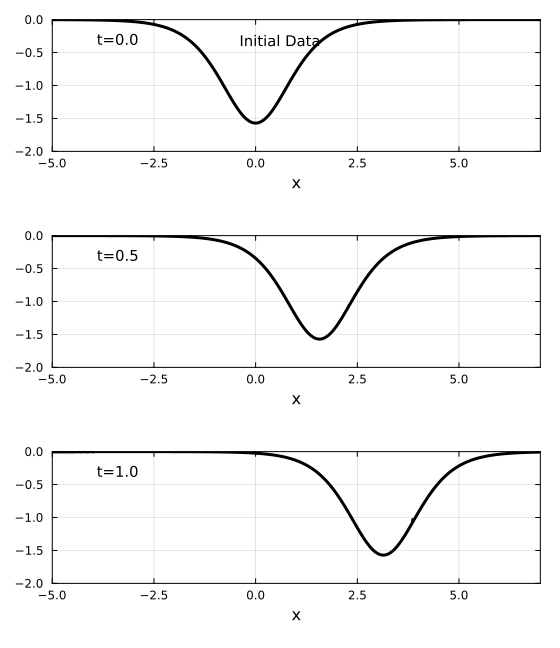

In [89]:
data92 = example92_scattering_data(c=PI_T)
x92 = collect(range(-5.0, 7.0; length=settings.plot_nx))

plt92 = plot(layout=(3, 1), size=(560, 650), margin=3Plots.mm)
errors92 = RealT[]
for (i, t) in enumerate(section93_times.example92)
    result = kdv_ist_solution(data92.right, data92.left, x92, t; Ns=max(settings.inverse_Ns, 8), Ni=settings.inverse_Ni)
    exact = paper_example92_exact.(x92, t)
    interior = 5:(length(x92)-4)
    push!(errors92, maximum(abs.(result.q[interior] .- exact[interior])))
    plot!(plt92[i], x92, result.q; label=false, color=:black, xlims=(-5, 7), ylims=(-2, 0), xlabel="x")
    annotate!(plt92[i], -3.4, -0.3, text("t=$t", 10, :black))
    i == 1 && annotate!(plt92[i], 0.6, -0.32, text("Initial Data", 10, :black))
end

@show errors92
plt92

## Example 9.1: direct scattering from $q(x)=xe^{-x^2}$

The paper reports one eigenvalue and norming constants:

$$
\lambda_1\approx -0.0138384593995,
\qquad \alpha_1^-\approx 0.2055954681199,
\qquad \alpha_1^+\approx 0.0416040800785.
$$

The smoke setting is intended to verify the pipeline quickly. Switch to `RUN_MODE = :paper` for a slower validation run. For the closest Example 9.1 eigenvalue match with the current unscaled SPPS recurrence, temporarily use `direct_L = 20`, `direct_nx = 32001`, and `direct_Ncoeff = 40`; this matches the paper eigenvalue to about $8\times 10^{-12}$. The default settings below are lighter so the notebook remains interactive.

The plotted direct-scattering examples use `DIRECT_EXAMPLE_BRANCH = :left`, i.e. the inverse problem from $J^-$ over the whole plotted interval. The paper's ISTM overview permits using either $J^+$ or $J^-$. In this notebook the direct $s^+(\rho)$ reflection data currently create a nonphysical stitch artifact near $x=0$ when `:paper_stitch` is used. The `t=0` panel plots the known input $q(x)$ exactly, because the numerical inverse reconstruction differentiates $a_0$ or $b_0$ twice and can show small tail oscillations where the exact Example 9.1 profile is already near zero. Nonzero-time panels are still computed from IST-evolved scattering data. Example 9.3 also uses a higher Appendix A truncation, `example93_Ncoeff = 80`, and `example93_Ns = 11` in paper mode.

data91.discrete.lambda = [-0.013838459094997575]
data91.discrete.alpha_minus = [0.20559546482555005]
data91.discrete.alpha_plus = [0.04160408016128639]
Example 9.1 direct-data errors: |Delta lambda|=3.045e-10, |Delta alpha-|=3.294e-09, |Delta alpha+|=8.279e-11


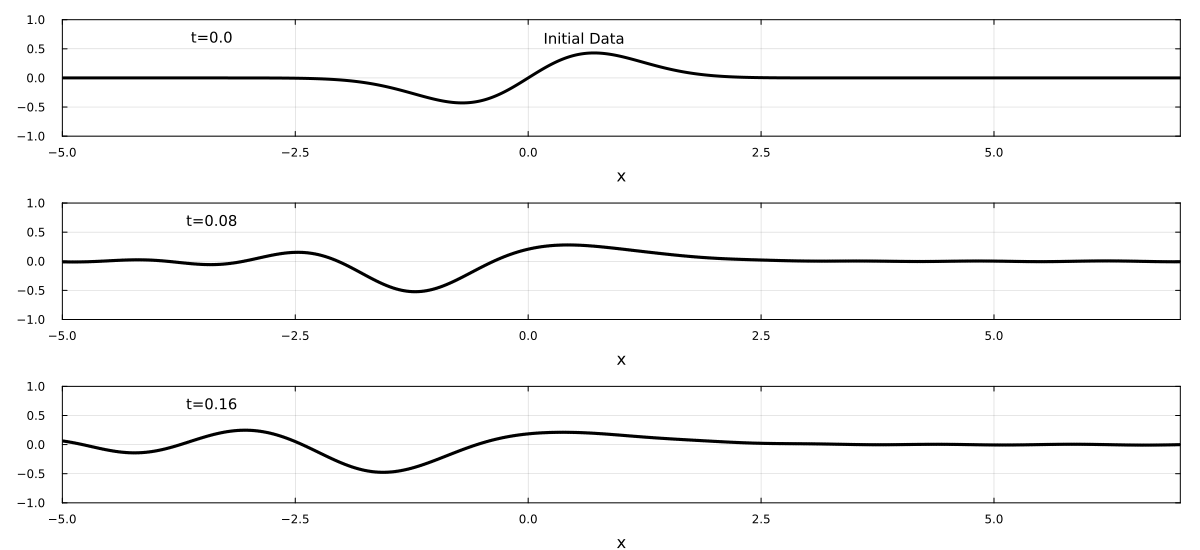

In [90]:
# This cell can take a while in :paper mode.
data91 = direct_scattering_istm(paper_example91_initial; L=settings.direct_L, nx=settings.direct_nx, Ncoeff=settings.direct_Ncoeff)
paper91_reference = (; lambda=RealT(-0.0138384593995), alpha_minus=RealT(0.2055954681199), alpha_plus=RealT(0.0416040800785))
@show data91.discrete.lambda
@show data91.discrete.alpha_minus
@show data91.discrete.alpha_plus
if !isempty(data91.discrete.lambda)
    @printf("Example 9.1 direct-data errors: |Delta lambda|=%.3e, |Delta alpha-|=%.3e, |Delta alpha+|=%.3e\n",
        abs(data91.discrete.lambda[1] - paper91_reference.lambda),
        abs(data91.discrete.alpha_minus[1] - paper91_reference.alpha_minus),
        abs(data91.discrete.alpha_plus[1] - paper91_reference.alpha_plus))
end

x91 = collect(range(-5.0, 7.0; length=settings.plot_nx))
plt91 = plot(layout=(3, 1), size=(1200, 550), margin=3Plots.mm)
for (i, t) in enumerate(section93_times.example91)
    qplot = plotted_kdv_profile(paper_example91_initial, data91.right, data91.left, x91, t; Ns=settings.inverse_Ns, Ni=settings.inverse_Ni, branch=DIRECT_EXAMPLE_BRANCH)
    plot!(plt91[i], x91, qplot; label=false, color=:black, xlims=(-5, 7), ylims=(-1, 1), xlabel="x")
    annotate!(plt91[i], -3.4, 0.7, text("t=$t", 10, :black))
    i == 1 && annotate!(plt91[i], 0.6, 0.68, text("Initial Data", 10, :black))
end
plt91

## Example 9.3: discontinuous derivative initial data

The initial condition is

$$
q(x)=\begin{cases}
e^x\cos(4x), & x<0,\\
e^{-x}J_0(2x), & x>0.
\end{cases}
$$

The paper used nine equations in the truncated finite-section systems for this example. The function is continuous at $x=0$ with $q(0)=1$ by one-sided limits, while its first derivative is discontinuous.

data93.discrete.lambda = Float64[]
data93.discrete.alpha_minus = Float64[]
data93.discrete.alpha_plus = Float64[]


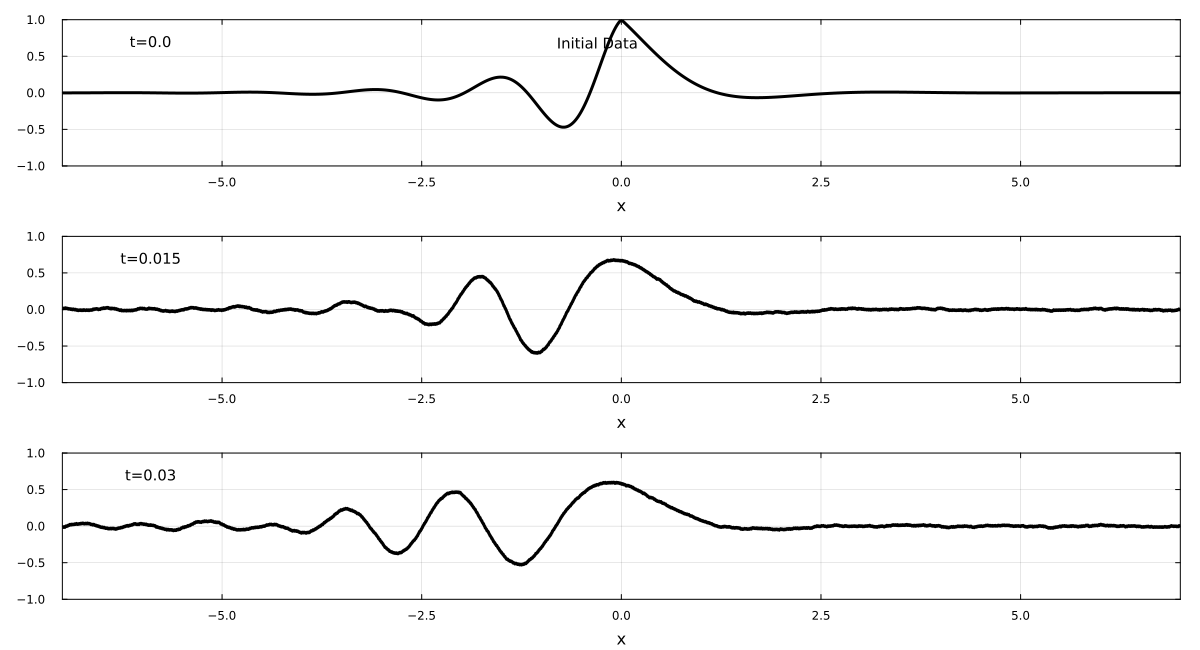

In [91]:
# This cell can take a while in :paper mode.
data93 = direct_scattering_istm(paper_example93_initial; L=settings.direct_L, nx=settings.direct_nx, Ncoeff=example93_Ncoeff)
@show data93.discrete.lambda
@show data93.discrete.alpha_minus
@show data93.discrete.alpha_plus

x93 = collect(range(-7.0, 7.0; length=settings.plot_nx))
plt93 = plot(layout=(3, 1), size=(1200, 650), margin=3Plots.mm)
for (i, t) in enumerate(section93_times.example93)
    qplot = plotted_kdv_profile(paper_example93_initial, data93.right, data93.left, x93, t; Ns=example93_Ns, Ni=settings.inverse_Ni, branch=DIRECT_EXAMPLE_BRANCH)
    plot!(plt93[i], x93, qplot; label=false, color=:black, xlims=(-7, 7), ylims=(-1, 1), xlabel="x")
    annotate!(plt93[i], -5.9, 0.7, text("t=$t", 10, :black))
    i == 1 && annotate!(plt93[i], -0.3, 0.68, text("Initial Data", 10, :black))
end
# plt93
# plot!(plt93; size=(800, 900))
plt93

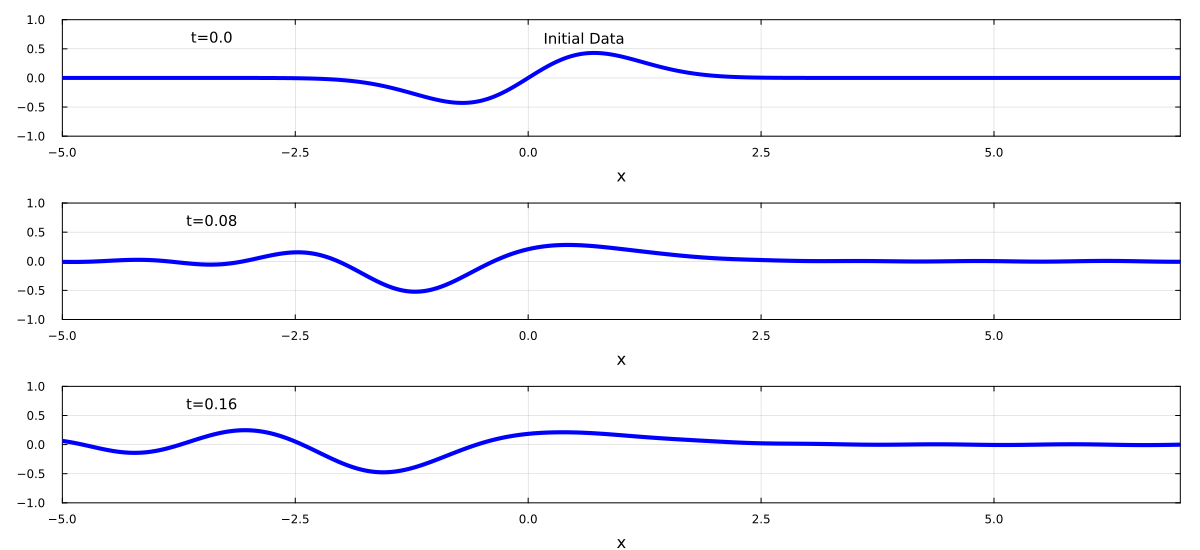

In [92]:
for sp in plt91.subplots
    for s in sp.series_list
        s[:linecolor] = :blue;
        s[:linewidth] = 4
    end
end

display(plt91)

## Save figures and summary

This final cell writes the notebook-generated figures and a compact validation summary. It is safe to rerun after switching between smoke and paper modes.

In [93]:
outdir = joinpath(repo_root, "figures", "istm_notebook")
mkpath(outdir)

isdefined(Main, :plt92) && savefig(plt92, joinpath(outdir, "example92_finite_section_ist.png"))
isdefined(Main, :plt91) && savefig(plt91, joinpath(outdir, "example91_istm.png"))
isdefined(Main, :plt93) && savefig(plt93, joinpath(outdir, "example93_istm.png"))

summary_path = joinpath(outdir, "summary.txt")
open(summary_path, "w") do io
    println(io, "ISTM finite-section notebook summary")
    println(io, "RUN_MODE = $RUN_MODE")
    if isdefined(Main, :errors92)
        println(io, "Example 9.2 max errors: ", errors92)
    end
    if isdefined(Main, :data91)
        println(io, "Example 9.1 lambdas: ", data91.discrete.lambda)
        println(io, "Example 9.1 alpha_minus: ", data91.discrete.alpha_minus)
        println(io, "Example 9.1 alpha_plus: ", data91.discrete.alpha_plus)
        if isdefined(Main, :paper91_reference) && !isempty(data91.discrete.lambda)
            println(io, "Example 9.1 direct-data errors: ", (
                lambda=abs(data91.discrete.lambda[1] - paper91_reference.lambda),
                alpha_minus=abs(data91.discrete.alpha_minus[1] - paper91_reference.alpha_minus),
                alpha_plus=abs(data91.discrete.alpha_plus[1] - paper91_reference.alpha_plus)))
        end
    end
    if isdefined(Main, :data93)
        println(io, "Example 9.3 lambdas: ", data93.discrete.lambda)
        println(io, "Example 9.3 alpha_minus: ", data93.discrete.alpha_minus)
        println(io, "Example 9.3 alpha_plus: ", data93.discrete.alpha_plus)
    end
end
summary_path

"/Users/fudong/Desktop/ResearchProjects/NumIST/figures/istm_notebook/summary.txt"